# Assignment 4 - dimer basics


Note: it may not look like there's a whole lot of code on this assignment - but don't be deceived, there's a few pictures to draw programattically.

## 1. Spanning trees on the grid

For this problem we're going to verify a curious formula: the number of spanning trees on the $m \times n$ grid graph is
$$
\frac{1}{mn} \prod_{i,j}\left (4 - 2 \cos \frac{i\pi}{m} - 2 \cos \frac{j \pi}{n} \right )
$$

where the product is taken over all pairs $(i,j)$ with $(i,j) \neq (0,0), 0 \leq i < m, 0 \leq j < n$.

(a) It is not obvious that the above quantity is an integer (or even a rational number).  Evaluate the formula for small $m,n$, and look up the corresponding numbers on the OEIS.  It's OK to use floating point for the sines and cosines, and round to the nearest integer.

(b) Let $\chi_n(x)$ be the characteristic polynomial of the Laplacian $\Delta_n$ of the $n$-path.  Write $\chi_n$ in terms of the [Chebyshev polynomials of the second kind](https://en.wikipedia.org/wiki/Chebyshev_polynomials).  

I knew to do this by computing $\chi_5 = x^5 - 8x^4 + 21x^3 - 20x^2 + 5x$, and then looking up those coefficients on the OEIS, which then told me to look up Chebyshev polynomials on Wikipedia.  You may take anything Wikipedia says about Chebyshev polynomials as true.

(c) Continue to use Wikipedia to learn what the roots of $\chi_n(x)$ are. Then use the matrix tree theorem to verify the formula above (I recommend the version which uses the Laplacian, not the reduced Laplacian).  This goes much like the problem, on a previous assignment, where you computed the eigenvalues of the adjacency matrix of the hypercube.

(Note: I mentioned in class that the count of perfect matchings on the $m \times n$ grid has a similar form, and you prove it in a similar way).

## 2. Temperley on a slightly truncated grid

Let $G'$ be a $2m-1$ by $2n-1$ grid with a corner removed.  

(a) Using Problem (3) and Temperley's bijection, count the perfect matchings on $G'$ by realizing $G'$ as the double graph of another (hauntingly familiar) graph $G$.

(b) Implement Temperley's bijection, in code, for this graph; use it to find a perfect matching on $G'$ when $m=3, n=4$. Make sure that it will work on an arbitrarily chosen spanning tree on $G$ (say, by choosing random edge weights and selecting a minimal spanning tree as per last assignment).  Draw a picture of the perfect matching.



## 3. The spider move
This problem is about a graph transformation which has a predictable effect on the dimer model partition function.

Consider edge-weighted planar, bipartite graphs $G$, $G'$ as follows. $G$ and $G'$ are identical, except $G$ has the left subgraph somewhere (a "spider"), and G' has the right subgraph (a "square") in the corresponding place.  The weights of these two graphs are related as follows:

$$A = \frac{a}{ab+cd}, B = \frac{b}{ab+cd}, C=\frac{c}{ab+cd}, D=\frac{d}{ab+cd}.$$
If $Z(G)$ and $Z(G')$ are the dimer model partition functions for the two graphs, show that $Z(G) = (ab+cd)Z(G')$.

Also: What does `ax.scatter(*zip*(square_points))` do, and why does it do that?

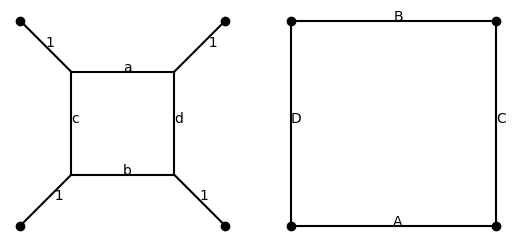

In [76]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(1,2)
spider_points = [(0,0), (1,1), (3,1), (4,0), (0,4), (1,3), (3,3), (4,4)]
spider_edges = [(0,1,"  1"), (1,2,"b"), (2,3,"1"), (4,5,"1"), (5,6,"a"), (6,7,"  1"),(1,5,"c"), (2,6,"d")]

square_points = [(0,0), (4,0), (4,4), (0,4)]
square_edges = [(0,1, "A"), (1,2, "C"), (2,3,"B"), (3,0,"D")]

for points, edges, axis in [(square_points, square_edges, ax[1]), (spider_points, spider_edges, ax[0])]:
    x, y = zip(*points)
    axis.set_aspect(1)
    axis.axis('off')
    for (a,b,label) in edges:
        x,y = zip(*[points[a], points[b]])
        axis.plot(x,y,color='black')
        axis.text(np.mean(x), np.mean(y), label) 

ax[0].scatter(*zip(*square_points), color="black")
ax[1].scatter(*zip(*square_points), color="black")



## 4. Pendant Edges, Double edge Collapse, Gauge Transform
In this problem we study three "easier" moves which have a predictable effect on the dimer partition function.  All the graphs in this problem are planar bipartite, and edge-weighted.

(a) Let $G$ be a weighted graph with a degree 1 vertex $v$, and an edge $(v,w)$ with weight 1.  Let $G'$ be the induced subgraph of $G$ in which $v, w$ are deleted.  Explain why $Z(G) = Z(G')$.  $(v,w)$ is called a "pendant" edge.

(b) Let $G$ be a graph with a degree 2 vertex $v$, and edges $(a,v)$ and $(v,b)$ with weight 1.  Let $G'$ be the quotient graph in which vertices $a,v,b$ are identified.  Explain why $Z(G) = Z(G')$.  This move is called "double edge collapse."

(c) Let $G$ be a graph with a vertex $v$ and edges $e_1, e_2, \dots, e_k$ incident to $v$.  If we multiply the weights of edges $e_1, e_2, e_3$ by $a$, what effect does this have on $Z(G)$?  This move is called a "Gauge transform" for reasons that are not completely clear to me.

## 5. Aztec Diamond

We now use everything we did in the above two problems to count perfect matchings on the order-$n$ Aztec diamond graph which I defined in lecture, and draw below.  All of its edge weights are 1.

Using the moves described above, show that $Z(AD_n) = 2^{n}Z(AD_{n-1}).$  Illustrate this when $n=3$.


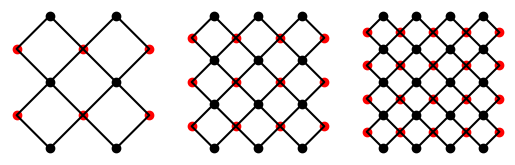

In [85]:

def aztec_diamond_picture(ax, n):
    ax.set_aspect(1)
    ax.axis("off")
    for t in range(1,2*n,2):
        ax.plot([t,2*n,2*n-t,0,t], [0,2*n-t,2*n,t,0], color="black")
    
    black_vertices = [(x,y) for x in range(1,2*n,2) for y in range(0,2*n+1,2)]
    ax.scatter(*zip(*black_vertices), color="black")
    red_vertices = [(x,y) for x in range(0,2*n+1,2) for y in range(1,2*n,2)]
    ax.scatter(*zip(*red_vertices), color="red", alpha=1)


fig, ax = plt.subplots(1,3)
aztec_diamond_picture(ax[0], 2)
aztec_diamond_picture(ax[1], 3)
aztec_diamond_picture(ax[2], 4)

